In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# QUESTION 1 — Classification: Car Evaluation Dataset

In [ ]:
car_data = pd.read_csv("/content/drive/MyDrive/MLCode/dataset/C/C.csv")

In [ ]:
car_data = car_data.loc[:, ~car_data.columns.str.contains('^Unnamed')]

print("Dataset shape:", car_data.shape)
print(car_data.head())


Dataset shape: (1728, 7)
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [ ]:
features_raw = car_data.drop('class', axis=1)
labels = car_data['class']

# Encode categorical features using OrdinalEncoder
enc = OrdinalEncoder()
features_encoded = pd.DataFrame(
    enc.fit_transform(features_raw),
    columns=features_raw.columns
)

print("\nEncoded features (first 5 rows):")
print(features_encoded.head())


feat_train, feat_test, lbl_train, lbl_test = train_test_split(
    features_encoded, labels, test_size=0.25, random_state=7
)

#Cross-Validation Setup
kfold = KFold(n_splits=5, shuffle=True, random_state=7)


Encoded features (first 5 rows):
   buying  maint  doors  persons  lug_boot  safety
0     3.0    3.0    0.0      0.0       2.0     1.0
1     3.0    3.0    0.0      0.0       2.0     2.0
2     3.0    3.0    0.0      0.0       2.0     0.0
3     3.0    3.0    0.0      0.0       1.0     1.0
4     3.0    3.0    0.0      0.0       1.0     2.0


Q1 Part 1 — CART (Gini) Decision Tree: Find Optimal Depth T


[Q1 Part 1] Optimal Tree Depth (T*) : 12
[Q1 Part 1] Best CV Accuracy        : 0.9583


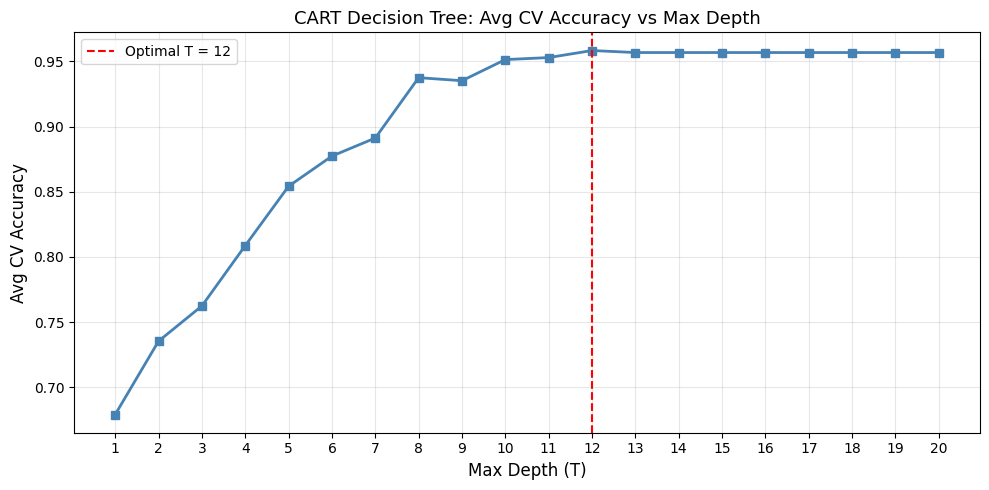

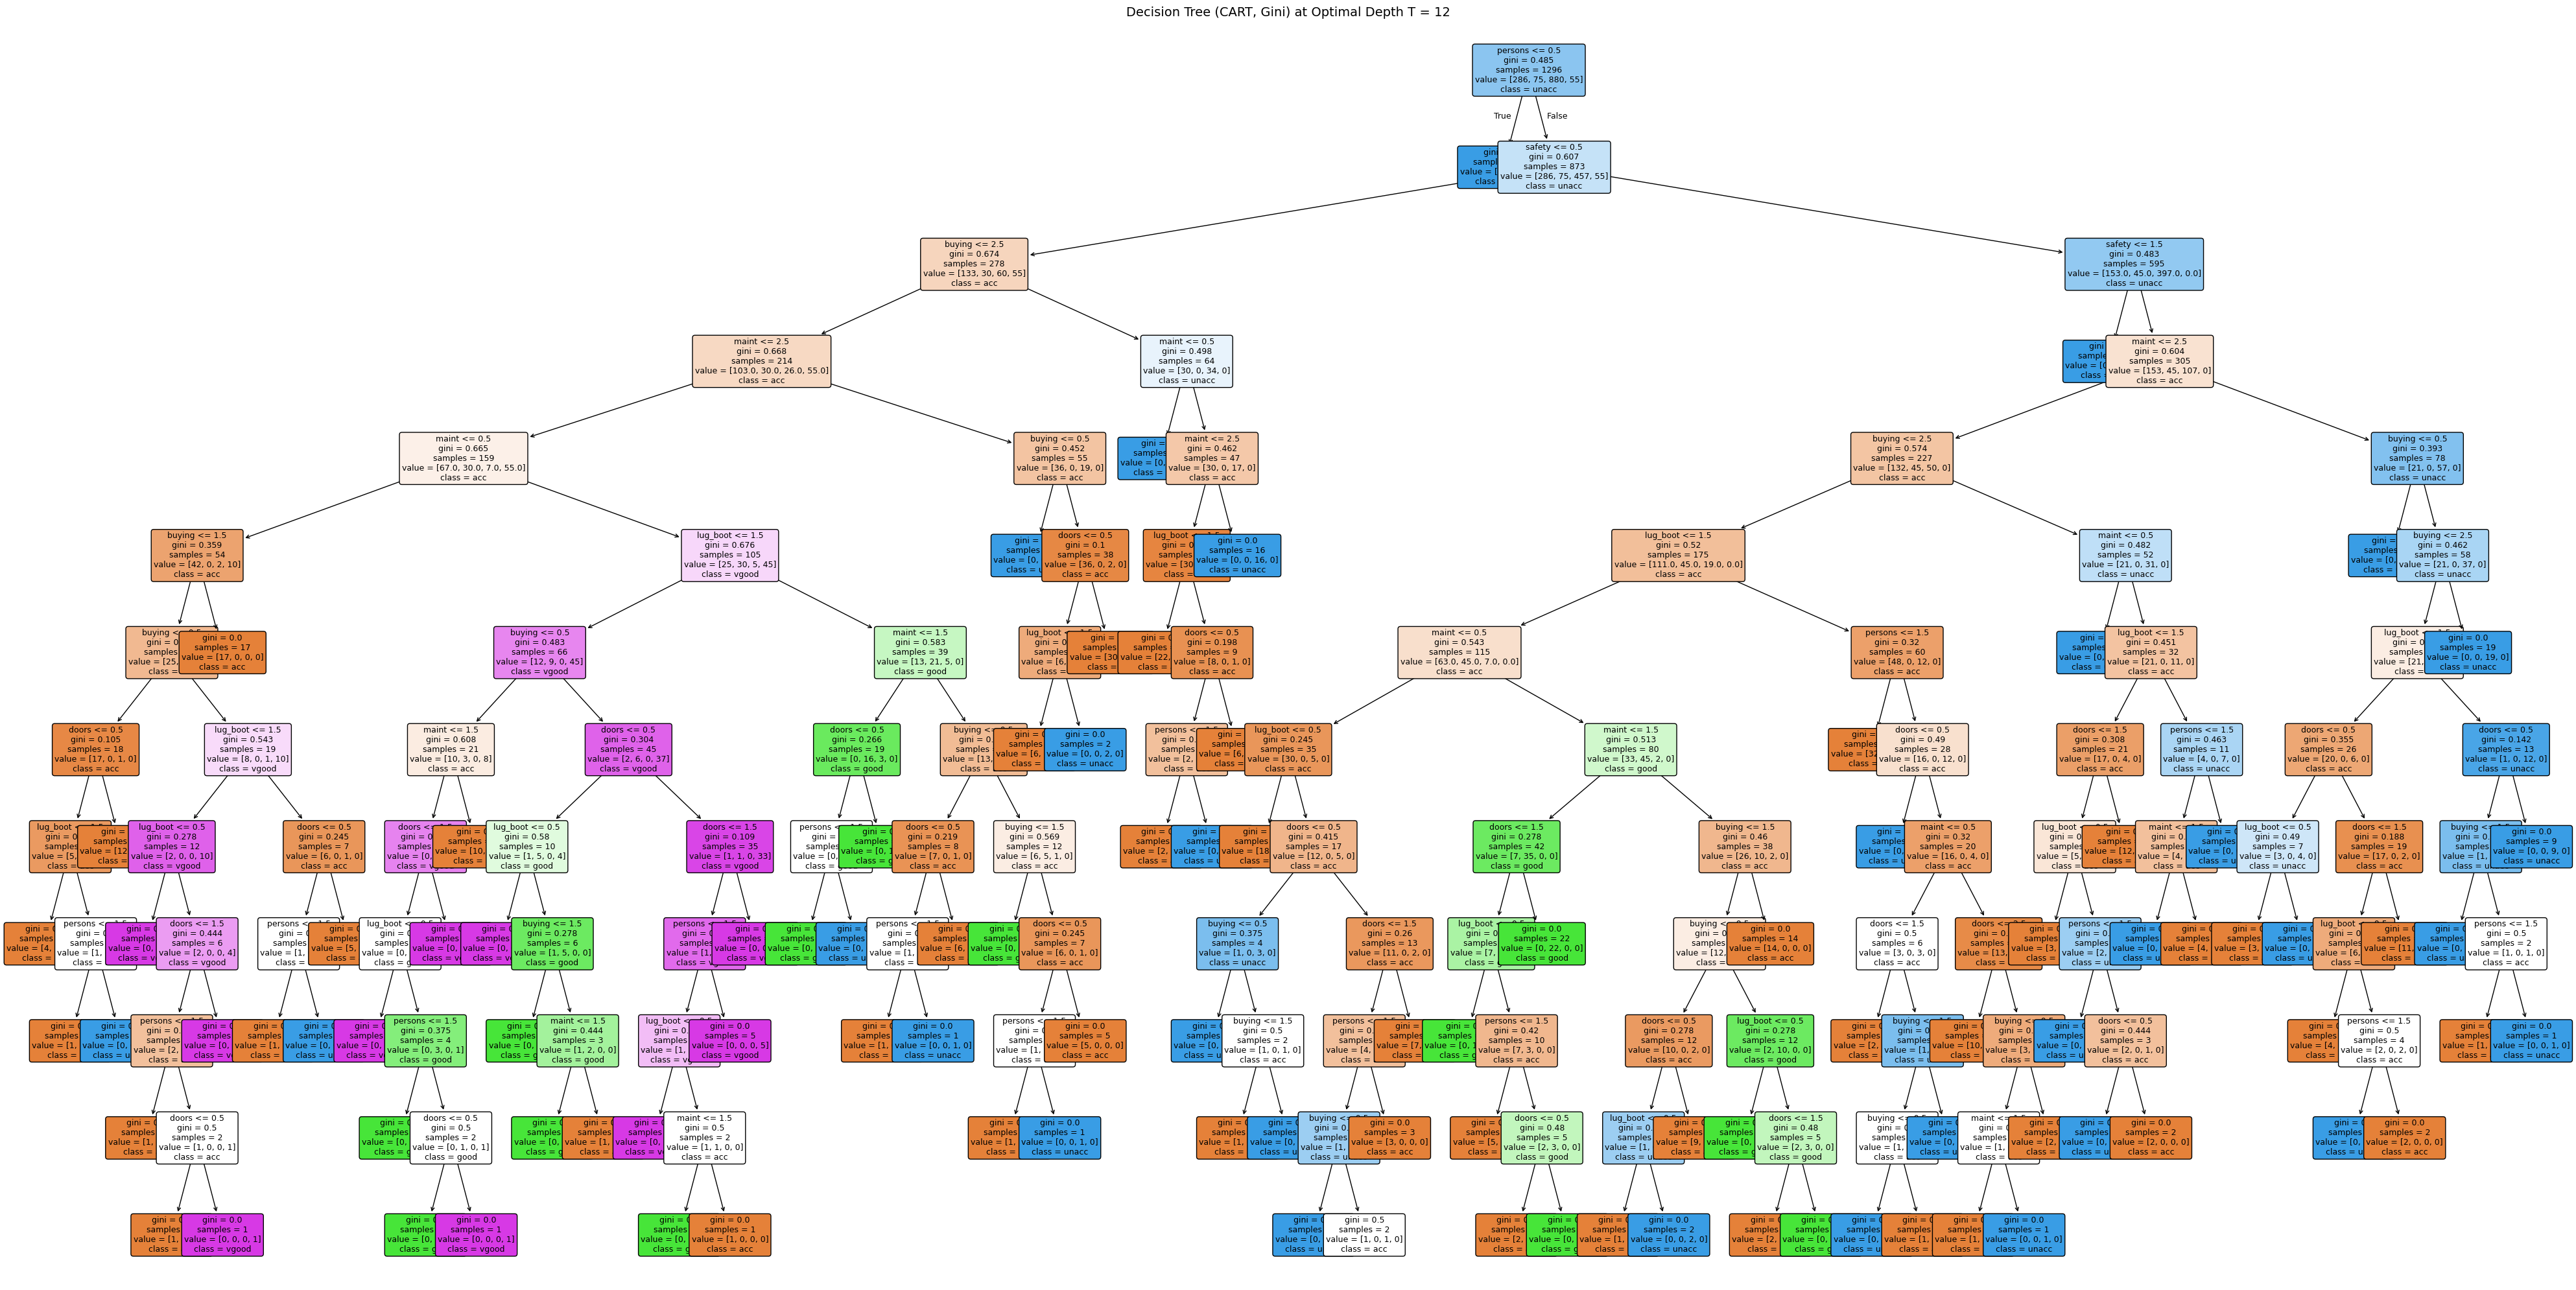

In [ ]:
depth_range      = list(range(1, 21))
mean_acc_by_depth = []

for depth in depth_range:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=7)
    fold_scores = cross_val_score(dt, feat_train, lbl_train, cv=kfold, scoring='accuracy')
    mean_acc_by_depth.append(fold_scores.mean())

best_depth = depth_range[np.argmax(mean_acc_by_depth)]
best_depth_acc = max(mean_acc_by_depth)

print(f"\n[Q1 Part 1] Optimal Tree Depth (T*) : {best_depth}")
print(f"[Q1 Part 1] Best CV Accuracy        : {best_depth_acc:.4f}")

# Plot: Avg Accuracy vs Max Depth
plt.figure(figsize=(10, 5))
plt.plot(depth_range, mean_acc_by_depth, marker='s', color='steelblue', linestyle='-', linewidth=2)
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Optimal T = {best_depth}')
plt.xlabel("Max Depth (T)", fontsize=12)
plt.ylabel("Avg CV Accuracy", fontsize=12)
plt.title("CART Decision Tree: Avg CV Accuracy vs Max Depth", fontsize=13)
plt.xticks(depth_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize Tree at Optimal Depth
optimal_tree = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=7)
optimal_tree.fit(feat_train, lbl_train)

plt.figure(figsize=(40, 20))
plot_tree(
    optimal_tree,
    feature_names=features_raw.columns.tolist(),
    class_names=np.unique(labels).tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(f"Decision Tree (CART, Gini) at Optimal Depth T = {best_depth}", fontsize=14)
plt.tight_layout()
plt.show()

Q1 Part 2 — Bagging: Find Optimal Number of Bootstrapped Datasets B


[Q1 Part 2] Optimal Bagging B*   : 200
[Q1 Part 2] Best CV Accuracy     : 0.9645
[Q1 Part 2] Test Accuracy (B=200): 98.15%


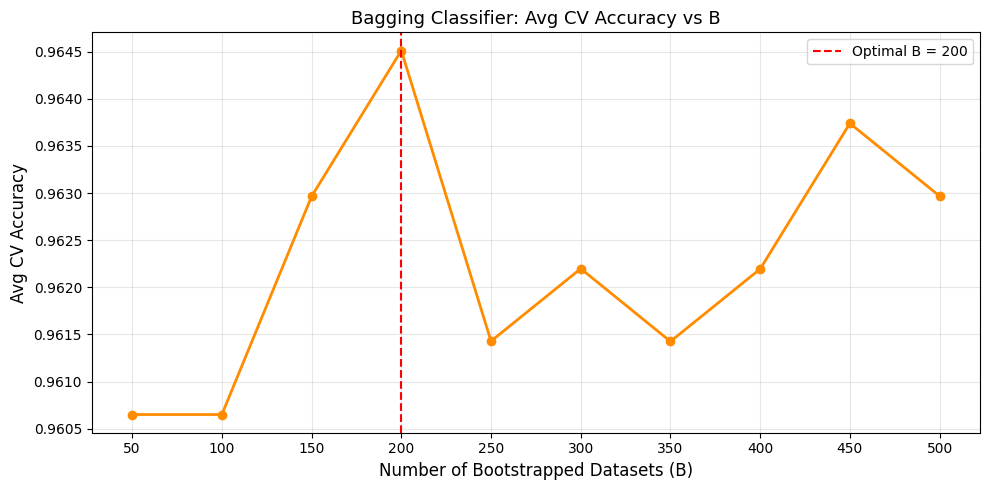

In [ ]:
num_estimators_range = list(range(50, 550, 50))
mean_acc_bagging     = []

base_estimator = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=7)

for n_est in num_estimators_range:
    bag_clf = BaggingClassifier(estimator=base_estimator, n_estimators=n_est, random_state=7)
    bag_scores = cross_val_score(bag_clf, feat_train, lbl_train, cv=kfold, scoring='accuracy')
    mean_acc_bagging.append(bag_scores.mean())

best_B      = num_estimators_range[np.argmax(mean_acc_bagging)]
best_B_acc  = max(mean_acc_bagging)

print(f"\n[Q1 Part 2] Optimal Bagging B*   : {best_B}")
print(f"[Q1 Part 2] Best CV Accuracy     : {best_B_acc:.4f}")

# Train at optimal B and evaluate on test set
final_bag_clf = BaggingClassifier(estimator=base_estimator, n_estimators=best_B, random_state=7)
final_bag_clf.fit(feat_train, lbl_train)
test_acc_bag = final_bag_clf.score(feat_test, lbl_test)
print(f"[Q1 Part 2] Test Accuracy (B={best_B}): {test_acc_bag * 100:.2f}%")

# Plot: Avg Accuracy vs B
plt.figure(figsize=(10, 5))
plt.plot(num_estimators_range, mean_acc_bagging, marker='o', color='darkorange', linestyle='-', linewidth=2)
plt.axvline(x=best_B, color='red', linestyle='--', label=f'Optimal B = {best_B}')
plt.xlabel("Number of Bootstrapped Datasets (B)", fontsize=12)
plt.ylabel("Avg CV Accuracy", fontsize=12)
plt.title("Bagging Classifier: Avg CV Accuracy vs B", fontsize=13)
plt.xticks(num_estimators_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Q1 Part 3 — Random Forest: m = 4

In [ ]:
# d = 6 features, so √d ≈ 2.45; valid m range is [3, 6]; using m = 4 as specified
m_features = 4

rf_clf = RandomForestClassifier(
    n_estimators=best_B,
    max_depth=best_depth,
    max_features=m_features,
    criterion='gini',
    random_state=7
)

rf_scores = cross_val_score(rf_clf, feat_train, lbl_train, cv=kfold, scoring='accuracy')
avg_rf_accuracy = rf_scores.mean()

print(f"\n[Q1 Part 3] Random Forest Config — B={best_B}, T={best_depth}, m={m_features}")
print(f"[Q1 Part 3] Avg CV Classification Accuracy: {avg_rf_accuracy:.4f}")



[Q1 Part 3] Random Forest Config — B=200, T=12, m=4
[Q1 Part 3] Avg CV Classification Accuracy: 0.9606


QUESTION 2 — Regression: Boston Housing Dataset


In [ ]:
# Load Dataset
housing_df = pd.read_csv("/content/drive/MyDrive/MLCode/dataset/C/boston_housing.csv")
housing_df = housing_df.dropna()

print("\nHousing dataset shape:", housing_df.shape)
print(housing_df.head())

# Feature / Target Split
house_features = housing_df.drop(columns=['MEDV'])
house_target   = housing_df['MEDV']

#  Train / Test Split
hf_train, hf_test, ht_train, ht_test = train_test_split(
    house_features, house_target, test_size=0.2, random_state=7
)

# Cross-validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=7)



Housing dataset shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


Q2 Part 1 — Regression Tree with min_samples_leaf S = 4


[Q2 Part 1] Regression Tree (S=4) — MSE: 20.9225 | R²: 0.7411


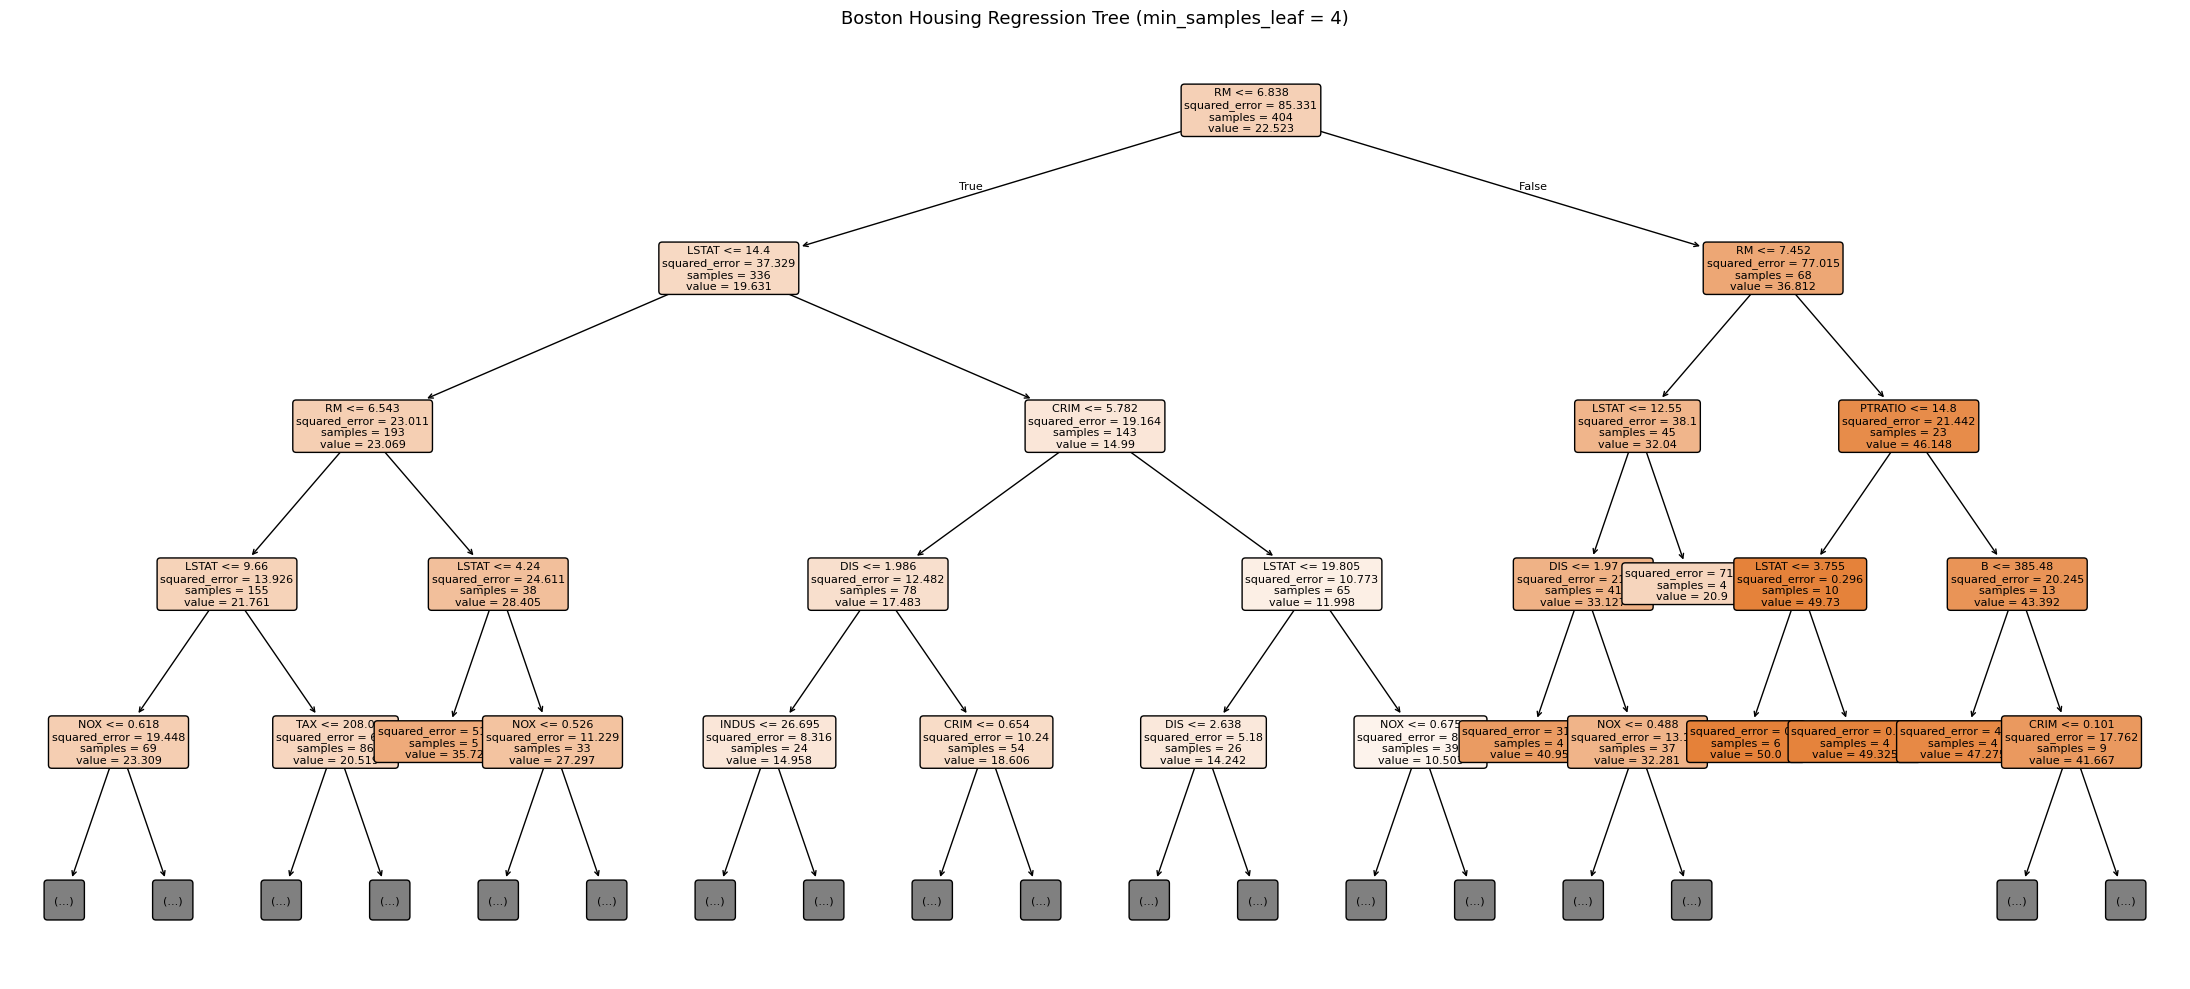

In [ ]:
S = 4  # minimum samples in a terminal node

reg_tree = DecisionTreeRegressor(min_samples_leaf=S, random_state=7)
reg_tree.fit(hf_train, ht_train)

ht_pred_tree = reg_tree.predict(hf_test)
tree_mse = mean_squared_error(ht_test, ht_pred_tree)
tree_r2  = r2_score(ht_test, ht_pred_tree)

print(f"\n[Q2 Part 1] Regression Tree (S={S}) — MSE: {tree_mse:.4f} | R²: {tree_r2:.4f}")

# ── Visualize Regression Tree (display depth limited to 4 for readability) ───
plt.figure(figsize=(22, 10))
plot_tree(
    reg_tree,
    feature_names=house_features.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title(f"Boston Housing Regression Tree (min_samples_leaf = {S})", fontsize=13)
plt.tight_layout()
plt.show()

Q2 Part 2 — Bagging for Regression: Find Optimal B


[Q2 Part 2] Optimal Bagging B* (Regression) : 450
[Q2 Part 2] Min Avg CV MSE                  : 13.4315
[Q2 Part 2] Test MSE: 21.8786 | Test R²: 0.7292


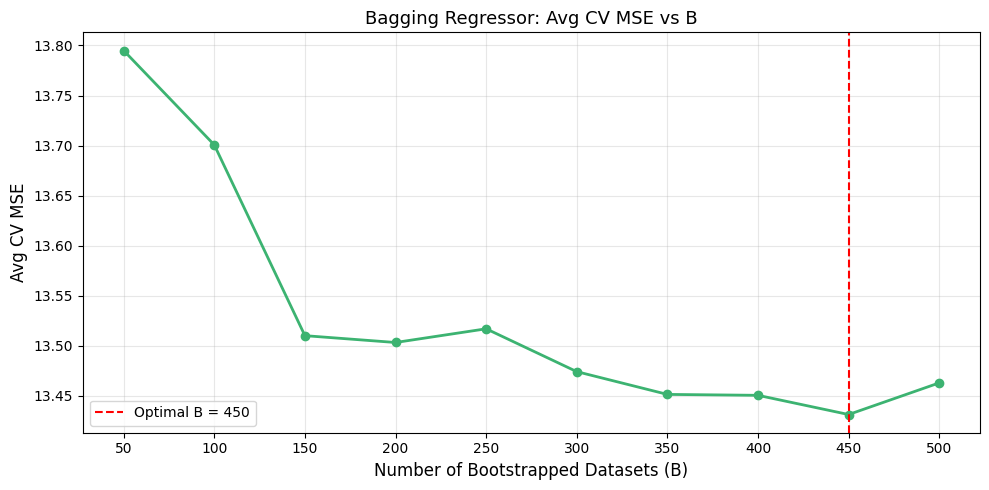

In [ ]:
bag_B_range      = list(range(50, 550, 50))
mean_mse_bagging = []

for n_est in bag_B_range:
    bag_reg = BaggingRegressor(estimator=reg_tree, n_estimators=n_est, random_state=7)
    mse_scores = cross_val_score(
        bag_reg, hf_train, ht_train, cv=kfold, scoring='neg_mean_squared_error'
    )
    mean_mse_bagging.append(-mse_scores.mean())

best_B_reg     = bag_B_range[np.argmin(mean_mse_bagging)]
min_mse_bagging = min(mean_mse_bagging)

print(f"\n[Q2 Part 2] Optimal Bagging B* (Regression) : {best_B_reg}")
print(f"[Q2 Part 2] Min Avg CV MSE                  : {min_mse_bagging:.4f}")

# Train at optimal B and evaluate
final_bag_reg = BaggingRegressor(estimator=reg_tree, n_estimators=best_B_reg, random_state=7)
final_bag_reg.fit(hf_train, ht_train)
ht_pred_bag = final_bag_reg.predict(hf_test)

bag_reg_mse = mean_squared_error(ht_test, ht_pred_bag)
bag_reg_r2  = r2_score(ht_test, ht_pred_bag)
print(f"[Q2 Part 2] Test MSE: {bag_reg_mse:.4f} | Test R²: {bag_reg_r2:.4f}")

# Plot: Avg MSE vs B
plt.figure(figsize=(10, 5))
plt.plot(bag_B_range, mean_mse_bagging, marker='o', color='mediumseagreen', linestyle='-', linewidth=2)
plt.axvline(x=best_B_reg, color='red', linestyle='--', label=f'Optimal B = {best_B_reg}')
plt.xlabel("Number of Bootstrapped Datasets (B)", fontsize=12)
plt.ylabel("Avg CV MSE", fontsize=12)
plt.title("Bagging Regressor: Avg CV MSE vs B", fontsize=13)
plt.xticks(bag_B_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Q2 Part 3 — Random Forest Regressor: m = 7

In [ ]:
# d = 13 features, √d ≈ 3.6; valid m range is [4, 13]; using m = 7 as specified
m_reg = 7

rf_reg = RandomForestRegressor(
    n_estimators=best_B_reg,
    min_samples_leaf=S,
    max_features=m_reg,
    random_state=7
)

rf_mse_cv = cross_val_score(rf_reg, hf_train, ht_train, cv=kfold, scoring='neg_mean_squared_error')
rf_r2_cv  = cross_val_score(rf_reg, hf_train, ht_train, cv=kfold, scoring='r2')

avg_rf_mse = -rf_mse_cv.mean()
avg_rf_r2  = rf_r2_cv.mean()

print(f"\n[Q2 Part 3] Random Forest Config — B={best_B_reg}, S={S}, m={m_reg}")
print(f"[Q2 Part 3] Avg CV MSE  : {avg_rf_mse:.4f}")
print(f"[Q2 Part 3] Avg CV R²   : {avg_rf_r2:.4f}")



[Q2 Part 3] Random Forest Config — B=450, S=4, m=7
[Q2 Part 3] Avg CV MSE  : 12.6477
[Q2 Part 3] Avg CV R²   : 0.8536


AI Usage Declaration


AI tools were used in a limited and supplementary capacity during the preparation of this assignment. Specifically, they were utilized for minor assistance in improving code structure, debugging small issues, and enhancing the clarity of visualizations such as plots generated using Matplotlib.

Additionally, AI support was occasionally referred to for better understanding certain Python operations (e.g., NumPy handling, data preprocessing steps) and refining implementation details while working in Google Colab.

However, the overall approach, model implementation (Decision Trees, Bagging, and Random Forests), parameter selection, performance evaluation, interpretation of results, and final conclusions were developed independently. The core logic and understanding demonstrated in this submission are entirely my own.

This declaration is made in accordance with the AI usage policy, ensuring that AI tools were used only as a learning aid and not as a substitute for original work.